# 评论情感分析

导包

In [2]:
# Standard libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.gridspec import GridSpec
pd.set_option('display.max_columns', 100)
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
import json
import requests
import folium
from folium.plugins import FastMarkerCluster, Fullscreen, MiniMap, HeatMap, HeatMapWithTime, LocateControl
from wordcloud import WordCloud
from collections import Counter
from PIL import Image

# Utilities
from viz_utils import *
from custom_transformers import *
from ml_utils import *

# DataPrep
import re
from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import joblib

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
import lightgbm as lgb

f:\_4.Pycode_integration\.venv\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning:


Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.




读数据

In [3]:
olist_customer = pd.read_csv('data/olist_public_dataset/olist_customers_dataset.csv')
olist_geolocation = pd.read_csv('data/olist_public_dataset/olist_geolocation_dataset.csv')
olist_orders = pd.read_csv('data/olist_public_dataset/olist_orders_dataset.csv')
olist_order_items = pd.read_csv('data/olist_public_dataset/olist_order_items_dataset.csv')
olist_order_payments = pd.read_csv('data/olist_public_dataset/olist_order_payments_dataset.csv')
olist_order_reviews = pd.read_csv('data/olist_public_dataset/olist_order_reviews_dataset.csv')
olist_products = pd.read_csv('data/olist_public_dataset/olist_products_dataset.csv')
olist_sellers = pd.read_csv('data/olist_public_dataset/olist_sellers_dataset.csv')

查看数据

In [9]:
# Collections for each dataset
# 数据集列表，包含所有需要分析的 DataFrame
datasets = [olist_customer, olist_geolocation, olist_orders, olist_order_items, olist_order_payments,
            olist_order_reviews, olist_products, olist_sellers]
# 数据集名称列表，与 datasets 中的 DataFrame 一一对应
names = ['olist_customer', 'olist_geolocation', 'olist_orders', 'olist_order_items', 'olist_order_payments',
         'olist_order_reviews', 'olist_products', 'olist_sellers']

# Creating a DataFrame with useful information about all datasets
# 创建一个包含所有数据集有用信息的 DataFrame
data_info = pd.DataFrame({})
# 添加数据集名称列
data_info['dataset'] = names
# 添加数据集行数列
data_info['n_rows'] = [df.shape[0] for df in datasets]
# 添加数据集列数列
data_info['n_cols'] = [df.shape[1] for df in datasets]
# 添加数据集空值总数列
data_info['null_amount'] = [df.isnull().sum().sum() for df in datasets]
# 添加数据集包含空值的列数列
data_info['qty_null_columns'] = [len([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]
# 添加数据集包含空值的列名列
data_info['null_columns'] = [', '.join([col for col, null in df.isnull().sum().items() if null > 0]) for df in datasets]

# 对 DataFrame 应用背景渐变样式
data_info.style.background_gradient()
# 将 DataFrame 导出为 CSV 文件（注释掉的代码）
# data_info.to_csv('export/sentiment/data_info.csv', index=False)

,dataset,n_rows,n_cols,null_amount,qty_null_columns,null_columns
0,olist_customer,99441,5,0,0,
1,olist_geolocation,1000163,5,0,0,
2,olist_orders,99441,8,4908,3,"order_approved_at, order_delivered_carrier_date, order_delivered_customer_date"
3,olist_order_items,112650,7,0,0,
4,olist_order_payments,103886,5,0,0,
5,olist_order_reviews,99224,7,145903,2,"review_comment_title, review_comment_message"
6,olist_products,32951,9,2448,8,"product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm"
7,olist_sellers,3095,4,0,0,


使用在viz_utils.py模块中找到的一个自制函数来查看每个数据集，并获取关于数据的一些详细参数。通过这个函数，我们可以获取每个数据集列的以下信息： 
- 列名；
- 空值数量；
- 相对于整个数据集的空值百分比；
- 数据类型；
- 总的分类条目数。


In [11]:
def get_dataset_details(df):
    # 获取数据集的详细信息，包括列名、空值数量、空值比例、数据类型和唯一值数量
    details = pd.DataFrame({})
    details['column_name'] = df.columns
    details['null_count'] = df.isnull().sum()
    details['null_percentage'] = (df.isnull().sum() / len(df)) * 100
    details['data_type'] = df.dtypes
    details['unique_count'] = df.nunique()
    return details




查看数据集的列，我们可以看到不同`status`状态的订单以及不同的时间戳列，如`purchase`（购买时间）、`approved`（批准时间）、`delivered`（交付时间）和`estimated delivery`（预计交付时间）。首先，让我们看看数据集中这些订单的状态。

* 每个状态的订单数量是多少？



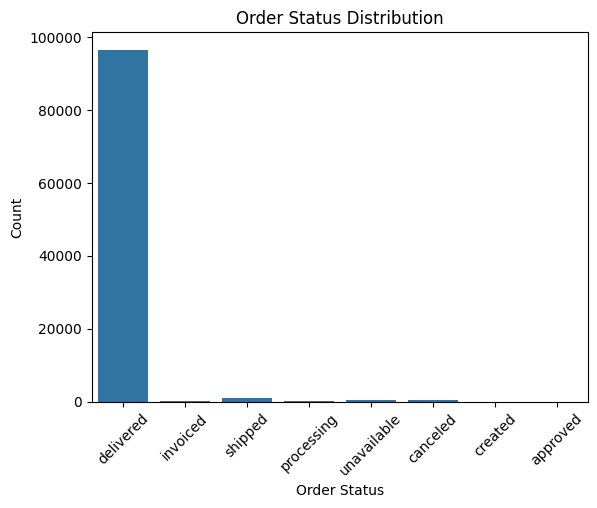

In [5]:

# 合并订单数据集和客户数据集
df_orders = olist_orders.merge(olist_customer, how='left', on='customer_id')
# 创建图形
fig, ax = plt.subplots()
# 使用 seaborn 的 countplot 函数绘制订单状态的计数图
sns.countplot(data=df_orders, x='order_status', ax=ax)
plt.title('Order Status Distribution')
plt.xlabel('Order Status')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


上图所示：已发货的订单数量最多。只有 3% 的订单来自其他状态
提取有关“order_purchase_timestamp”的一些信息：
1. 转换时间戳列；
2. 从这些日期时间列中提取时间属性（年、月、日、星期几和小时）；
3. 使用这些属性评估电子商务场景。

In [6]:
# 日期类型转换（向量化操作）
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at', 
                 'order_delivered_carrier_date', 'order_estimated_delivery_date']
df_orders[timestamp_cols] = df_orders[timestamp_cols].apply(pd.to_datetime)

# 时间属性提取（统一使用dt访问器）
df_orders = df_orders.assign(
    order_purchase_year = df_orders.order_purchase_timestamp.dt.year,
    order_purchase_month = df_orders.order_purchase_timestamp.dt.month,
    order_purchase_month_name = df_orders.order_purchase_timestamp.dt.strftime('%b'),
    order_purchase_year_month = df_orders.order_purchase_timestamp.dt.strftime('%Y%m'),
    order_purchase_date = df_orders.order_purchase_timestamp.dt.strftime('%Y%m%d'),
    order_purchase_day = df_orders.order_purchase_timestamp.dt.day,
    order_purchase_dayofweek = df_orders.order_purchase_timestamp.dt.dayofweek,
    order_purchase_dayofweek_name = df_orders.order_purchase_timestamp.dt.strftime('%a'),
    order_purchase_hour = df_orders.order_purchase_timestamp.dt.hour
)

# 时段分箱（添加分类类型优化）
hours_bins = [-0.1, 6, 12, 18, 23]
hours_labels = ['Dawn', 'Morning', 'Afternoon', 'Night']
df_orders['order_purchase_time_day'] = pd.cut(
    df_orders['order_purchase_hour'],
    bins=hours_bins,
    labels=hours_labels
).astype('category')

# 验证结果
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase_year,order_purchase_month,order_purchase_month_name,order_purchase_year_month,order_purchase_date,order_purchase_day,order_purchase_dayofweek,order_purchase_dayofweek_name,order_purchase_hour,order_purchase_time_day
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017,10,Oct,201710,20171002,2,0,Mon,10,Morning
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018,7,Jul,201807,20180724,24,1,Tue,20,Night
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018,8,Aug,201808,20180808,8,2,Wed,8,Morning
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017,11,Nov,201711,20171118,18,5,Sat,19,Night
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018,2,Feb,201802,20180213,13,1,Tue,21,Night


-
我们使用 `GridSpec` 绘制三个图表，研究：1. 巴西电子商务是否存在增长趋势？2. 巴西消费者通常在一周中的哪一天进行网购？3. 巴西消费者通常在什么时间段购物（凌晨、上午、下午或晚上）？

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\1254313840.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\1254313840.py:29: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\1254313840.py:34: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




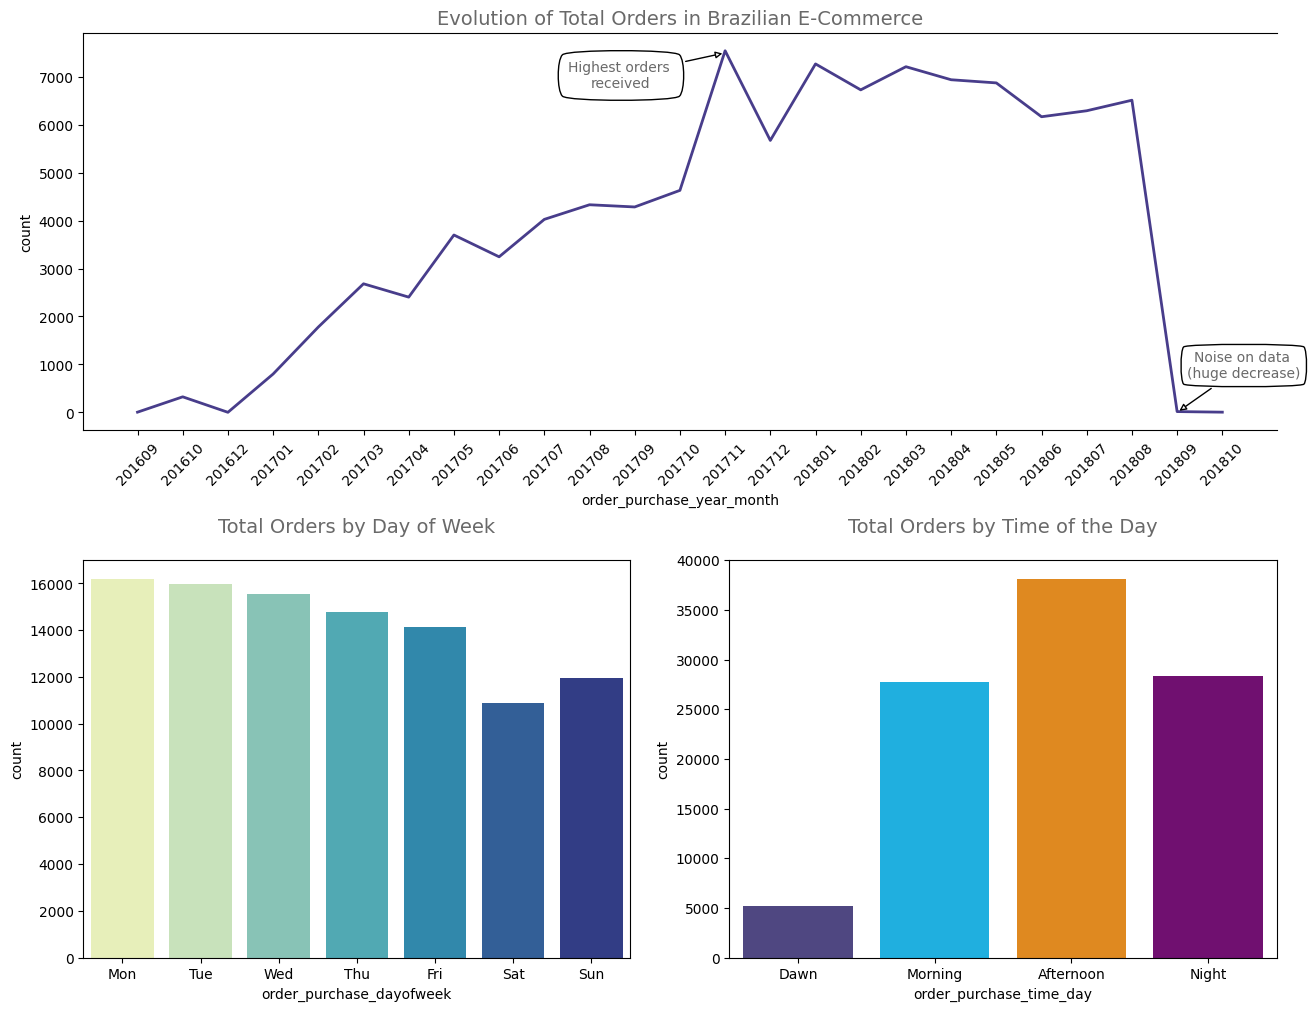

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(constrained_layout=True, figsize=(13, 10))

# Axis definition
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# Lineplot - Evolution of e-commerce orders along time 
sns.lineplot(data=df_orders['order_purchase_year_month'].value_counts().sort_index(), ax=ax1, 
             color='darkslateblue', linewidth=2)
ax1.annotate(f'Highest orders \nreceived', (13, 7500), xytext=(-75, -25), 
             textcoords='offset points', bbox=dict(boxstyle="round4", fc="w", pad=.8),
             arrowprops=dict(arrowstyle='-|>', fc='w'), color='dimgrey', ha='center')
ax1.annotate(f'Noise on data \n(huge decrease)', (23, 0), xytext=(48, 25), 
             textcoords='offset points', bbox=dict(boxstyle="round4", fc="w", pad=.5),
             arrowprops=dict(arrowstyle='-|>', fc='w'), color='dimgrey', ha='center')
ax1.spines['right'].set_visible(False)  # 手动设置右边框不可见
for tick in ax1.get_xticklabels():
    tick.set_rotation(45)
ax1.set_title('Evolution of Total Orders in Brazilian E-Commerce', size=14, color='dimgrey')

# Barchart - Total of orders by day of week
sns.countplot(data=df_orders, x='order_purchase_dayofweek', ax=ax2, palette='YlGnBu')
weekday_label = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
ax2.set_xticklabels(weekday_label)
ax2.set_title('Total Orders by Day of Week', size=14, color='dimgrey', pad=20)

# Barchart - Total of orders by time of the day
day_color_list = ['darkslateblue', 'deepskyblue', 'darkorange', 'purple']
sns.countplot(data=df_orders, x='order_purchase_time_day', ax=ax3, palette=day_color_list)
ax3.set_title('Total Orders by Time of the Day', size=14, color='dimgrey', pad=20)

plt.show()


通过上述图表我们可以得出以下结论：

* 巴西的电子商务确实呈现随时间增长的趋势。虽然某些月份存在季节性峰值，但总体来看可以明显发现顾客比以往更倾向于在线购物
周一和下午时段是巴西消费者的首选购物时间，他们更倾向于在下午完成交易
* 注：2018年8月至9月间数据出现急剧下降，可能与数据噪音有关。为了更准确地比较2017和2018年度数据，后续分析将仅考虑这两年1月至8月的订单数据

（保持原文的观察标记格式，将"Obs"译为"注"，并保留了时间跨度和比较方法的说明。专业术语如"seasonality"译为"季节性"，"sharp decrease"译为"急剧下降"，"noise on data"译为"数据噪音"等处理既准确又符合中文表达习惯。）

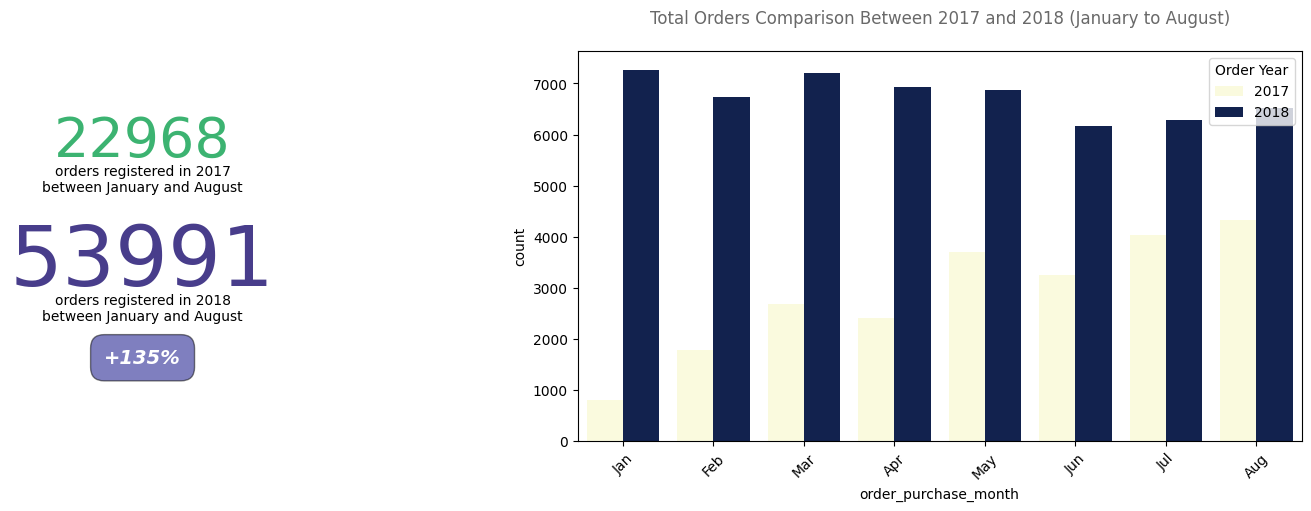

In [8]:
# Creating figure
fig = plt.figure(constrained_layout=True, figsize=(13, 5))

# Axis definition
gs = GridSpec(1, 3, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1:])

# 修正后的增长率计算
df_orders_compare = df_orders.query('order_purchase_year in (2017, 2018) & order_purchase_month <= 8')
year_orders = df_orders_compare['order_purchase_year'].value_counts()

# 正确计算公式（2018年相比2017年的增长率）
growth = int(round(100 * ((year_orders[2018] - year_orders[2017]) / year_orders[2017]), 0))

# Annotation 部分保持不变
ax1.text(0.00, 0.73, f'{year_orders[2017]}', fontsize=40, color='mediumseagreen', ha='center')
ax1.text(0.00, 0.64, 'orders registered in 2017\nbetween January and August', fontsize=10, ha='center')
ax1.text(0.00, 0.40, f'{year_orders[2018]}', fontsize=60, color='darkslateblue', ha='center')
ax1.text(0.00, 0.31, 'orders registered in 2018\nbetween January and August', fontsize=10, ha='center')
signal = '+' if growth > 0 else '-'
ax1.text(0.00, 0.20, f'{signal}{abs(growth)}%', fontsize=14, ha='center', color='white', style='italic', weight='bold',
         bbox=dict(facecolor='navy', alpha=0.5, pad=10, boxstyle='round, pad=.7'))
ax1.axis('off')

# 修正后的条形图设置
# 替换条形图部分
sns.countplot(data=df_orders_compare, 
             x='order_purchase_month', 
             hue='order_purchase_year', 
             ax=ax2,
             order=sorted(df_orders_compare['order_purchase_month'].unique()),
             palette='YlGnBu')


month_label = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug']
ax2.set_xticks(range(8))  # 明确设置刻度位置
ax2.set_xticklabels(month_label, rotation=45)  # 添加旋转
ax2.set_title('Total Orders Comparison Between 2017 and 2018 (January to August)', 
             size=12, color='dimgrey', pad=20)
plt.legend(loc='upper right', title='Order Year')  # 优化图例位置
plt.show()


为准备对巴西各州电子商务的分析数据，我们将采取以下步骤：

1. 合并订单数据到订单项数据；
2. 使用巴西政府的API返回每个customer_state的区域信息；
3. 制作有用的图表以回答业务问题。


In [ ]:
# 合并订单和订单项数据
df_orders_items = df_orders.merge(olist_order_items, how='left', on='order_id')

# 使用API获取巴西地区信息
r = requests.get('https://servicodados.ibge.gov.br/api/v1/localidades/mesorregioes')
content = [c['UF'] for c in json.loads(r.text)]
br_info = pd.DataFrame(content)
br_info['nome_regiao'] = br_info['regiao'].apply(lambda x: x['nome'])
br_info.drop('regiao', axis=1, inplace=True)
br_info.drop_duplicates(inplace=True)

# 处理巴西地图之外的经纬度数据
geo_prep = olist_geolocation[olist_geolocation.geolocation_lat <= 5.27438888]# 最北端
geo_prep = geo_prep[geo_prep.geolocation_lng >= -73.98283055]# 最西端
geo_prep = geo_prep[geo_prep.geolocation_lat >= -33.75116944]# 最南端
geo_prep = geo_prep[geo_prep.geolocation_lng <=  -34.79314722]# 最东端
geo_group = geo_prep.groupby(by='geolocation_zip_code_prefix', as_index=False).min()

# 合并所有信息
df_orders_items = df_orders_items.merge(br_info, how='left', left_on='customer_state', right_on='sigla')
df_orders_items = df_orders_items.merge(geo_group, how='left', left_on='customer_zip_code_prefix', 
                                        right_on='geolocation_zip_code_prefix')
df_orders_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_purchase_year,order_purchase_month,order_purchase_month_name,order_purchase_year_month,order_purchase_date,order_purchase_day,order_purchase_dayofweek,order_purchase_dayofweek_name,order_purchase_hour,order_purchase_time_day,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,id,sigla,nome,nome_regiao,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2017,10,Oct,201710,20171002,2,0,Mon,10,Morning,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,35,SP,São Paulo,Sudeste,3149.0,-23.583885,-46.587473,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,2018,7,Jul,201807,20180724,24,1,Tue,20,Night,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29,BA,Bahia,Nordeste,47813.0,-12.945892,-45.016313,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,2018,8,Aug,201808,20180808,8,2,Wed,8,Morning,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,52,GO,Goiás,Centro-Oeste,75265.0,-16.752735,-48.522139,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,2017,11,Nov,201711,20171118,18,5,Sat,19,Night,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,24,RN,Rio Grande do Norte,Nordeste,59296.0,-5.778488,-35.281450,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,2018,2,Feb,201802,20180213,13,1,Tue,21,Night,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,35,SP,São Paulo,Sudeste,9195.0,-23.760018,-46.524784,santo andre,SP


按地区、州和城市划分的客户订单概览

In [10]:
# Filtering data between 201701 and 201808
df_orders_filt = df_orders_items[(df_orders_items['order_purchase_year_month'].astype(int) >= 201701)]
df_orders_filt = df_orders_filt[(df_orders_filt['order_purchase_year_month'].astype(int) <= 201808)]

# 按区域对数据进行分组
df_regions_group = df_orders_filt.groupby(by=['order_purchase_year_month', 'nome_regiao'], as_index=False)
df_regions_group = df_regions_group.agg({'customer_id': 'count', 'price': 'sum'}).sort_values(by='order_purchase_year_month')
df_regions_group.columns = ['month', 'region', 'order_count', 'order_amount']
df_regions_group.reset_index(drop=True, inplace=True)

# 按城市分组数据（前 10 名）
df_cities_group = df_orders_filt.groupby(by='geolocation_city', 
                                       as_index=False).count().loc[:, ['geolocation_city', 'order_id']]
df_cities_group = df_cities_group.sort_values(by='order_id', ascending=False).reset_index(drop=True)
df_cities_group = df_cities_group.iloc[:10, :]

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2482795240.py:47: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2482795240.py:53: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




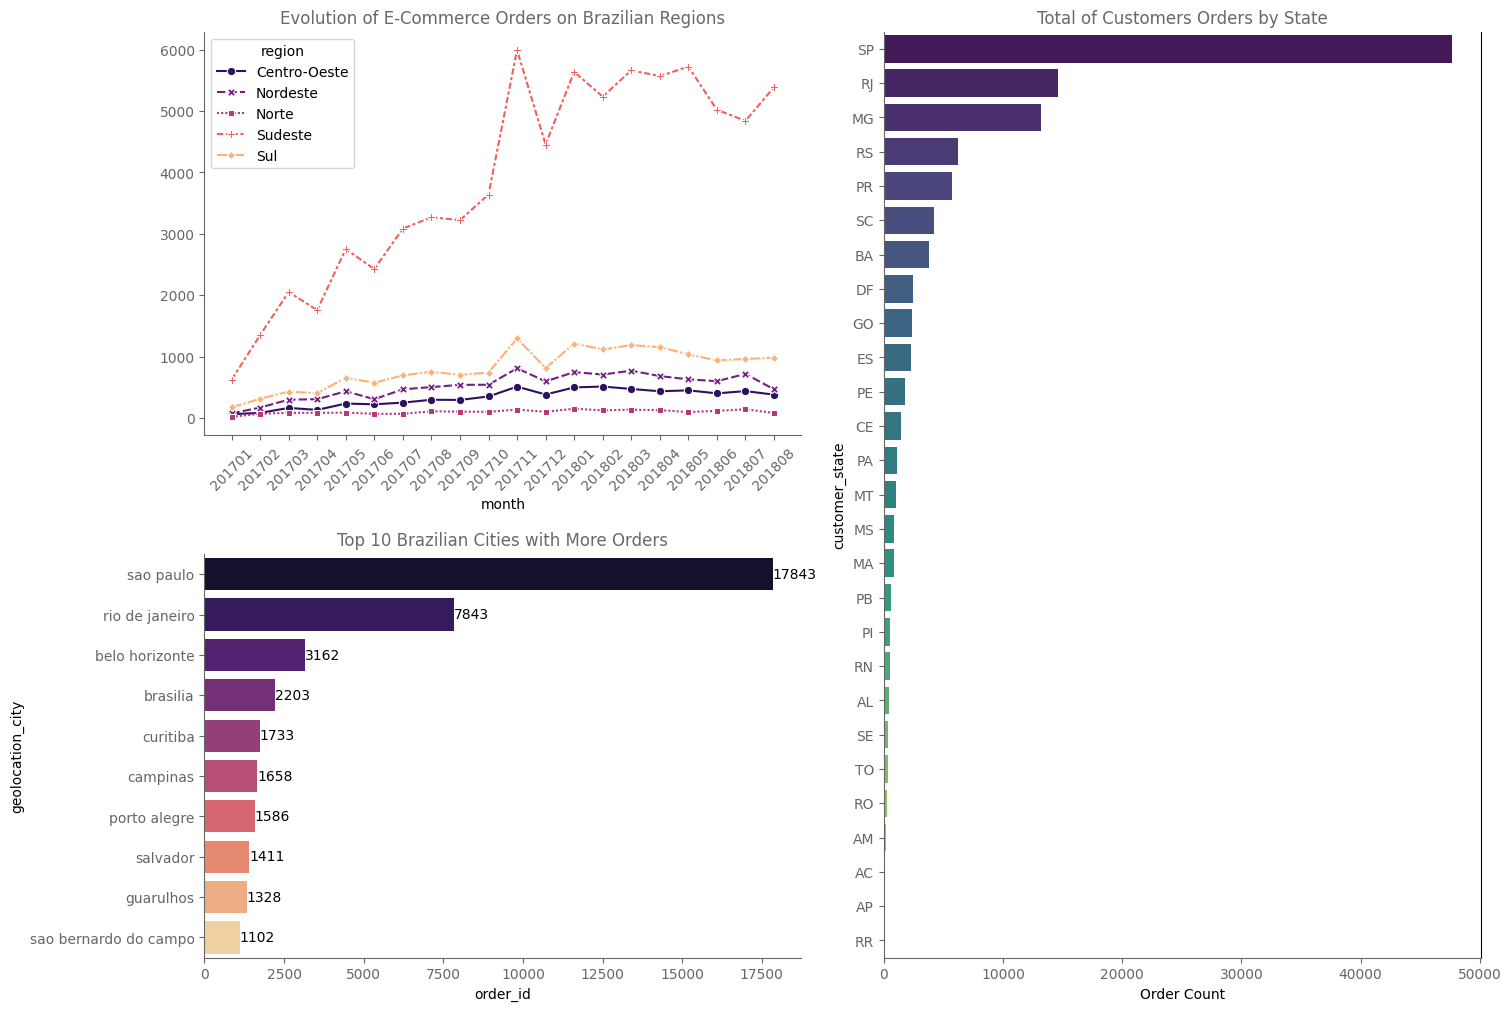

In [11]:
# 定义 format_spines 函数（保持不变）
def format_spines(ax, right_border=True):
    ax.spines['bottom'].set_color('#666666')
    ax.spines['left'].set_color('#666666')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(right_border)
    ax.tick_params(axis='x', colors='#666666')
    ax.tick_params(axis='y', colors='#666666')
    ax.patch.set_alpha(0.0)

# 创建单个 figure 和布局
fig = plt.figure(constrained_layout=True, figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[:, 1])

# 折线图参数修正
sns.lineplot(
    x='month', 
    y='order_count', 
    ax=ax1, 
    data=df_regions_group, 
    hue='region', 
    style='region',  # 移除 size 参数
    palette='magma', 
    markers=True  # 自动匹配标记
)
format_spines(ax1, right_border=False)
ax1.set_title('Evolution of E-Commerce Orders on Brazilian Regions', size=12, color='dimgrey')
ax1.set_ylabel('')
plt.setp(ax1.get_xticklabels(), rotation=45)

# 柱状图注释函数（简单实现）
def AnnotateBars(ax, n_dec=0, font_size=10, color='black'):
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + 0.01, 
                p.get_y() + p.get_height()/2, 
                f'{width:.{n_dec}f}', 
                ha='left', 
                va='center',
                fontsize=font_size,
                color=color)

# 修正柱状图
sns.barplot(y='geolocation_city', x='order_id', data=df_cities_group, ax=ax2, palette='magma')
AnnotateBars(ax2)  # 使用修正后的注释函数
format_spines(ax2, right_border=False)
ax2.set_title('Top 10 Brazilian Cities with More Orders', size=12, color='dimgrey')

# 使用标准 countplot 代替自定义函数
sns.countplot(
    y='customer_state', 
    ax=ax3, 
    data=df_orders_filt, 
    palette='viridis',
    order=df_orders_filt['customer_state'].value_counts().index
)
format_spines(ax3)  # 添加格式设置
ax3.set_title('Total of Customers Orders by State', size=12, color='dimgrey')
ax3.set_xlabel('Order Count')

plt.show()


客户分布

In [13]:
# Zipping locations
lats = list(df_orders_items.query('order_purchase_year == 2018')['geolocation_lat'].dropna().values)[:30000]
longs = list(df_orders_items.query('order_purchase_year == 2018')['geolocation_lng'].dropna().values)[:30000]
locations = list(zip(lats, longs))

# Creating a mapa using folium
map1 = folium.Map(location=[-15, -50], zoom_start=4.0)

# Plugin: FastMarkerCluster
FastMarkerCluster(data=locations).add_to(map1)
map1.save('map1.html')
map1

In [14]:
# Grouping geolocation data for plotting a heatmap
heat_data = df_orders_filt.groupby(by=['geolocation_lat', 'geolocation_lng'], as_index=False).count().iloc[:, :3]

# Creating a mapa using folium
map1 = folium.Map(
    location=[-15, -50], 
    zoom_start=4.0, 
    tiles='cartodbdark_matter'
)

# Plugin: HeatMap
HeatMap(
    name='Mapa de Calor',
    data=heat_data,
    radius=10,
    max_zoom=13
).add_to(map1)

map1
map1.save('heatmap.html')  # 保存为HTML文件


In [15]:
epoch_list = []
heatmap_evl_data = df_orders_items[(df_orders_items['order_purchase_year_month'].astype(int) >= 201801)]
heatmap_evl_data = heatmap_evl_data[(heatmap_evl_data['order_purchase_year_month'].astype(int) <= 201807)]
time_index = heatmap_evl_data['order_purchase_year_month'].sort_values().unique()
for epoch in time_index:
    data_temp = heatmap_evl_data.query('order_purchase_year_month == @epoch')
    data_temp = data_temp.groupby(by=['geolocation_lat', 'geolocation_lng'], as_index=False).count()
    data_temp = data_temp.sort_values(by='order_id', ascending=False).iloc[:, :3]
    epoch_list.append(data_temp.values.tolist())
    
# Creating a mapa using folium
map2 = folium.Map(
    location=[-15, -50], 
    zoom_start=4.0, 
    tiles='cartodbdark_matter'
)

# Plugin: HeatMapWithTime
HeatMapWithTime(
    name='Evolution of Orders in a Geolocation Perspective',
    data=epoch_list,
    radius=10,
    index=list(time_index)
).add_to(map2)

map2.save('map2.html')
map2


In [16]:
# Grouping data
df_month_aggreg = df_orders_filt.groupby(by=['order_purchase_year', 'order_purchase_year_month'], as_index=False)
df_month_aggreg = df_month_aggreg.agg({
    'order_id': 'count',
    'price': 'sum',
    'freight_value': 'sum'
})

# Adding new columns for analysis
df_month_aggreg['price_per_order'] = df_month_aggreg['price'] / df_month_aggreg['order_id']
df_month_aggreg['freight_per_order'] = df_month_aggreg['freight_value'] / df_month_aggreg['order_id']
df_month_aggreg.head()

,order_purchase_year,order_purchase_year_month,order_id,price,freight_value,price_per_order,freight_per_order
0,2017,201701,966,120312.87,16875.62,124.547484,17.469586
1,2017,201702,1998,247303.02,38977.60,123.775285,19.508308
2,2017,201703,3041,374344.30,57704.29,123.099079,18.975432
3,2017,201704,2697,359927.23,52495.01,133.454664,19.464223
4,2017,201705,4176,506071.14,80119.81,121.185618,19.185778


C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:32: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:94: UserWarning:

Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from current font.

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:94: UserWarning:

Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from current font.

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:94: UserWarning:

Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from current font.

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:94: UserWarning:

Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from current font.

C:\Users\yohoten\AppData\Local\Temp\ipykernel_36768\2413468547.py:94: UserWarning:

Glyph 21457 (\N{CJK UNIFIED IDEOG

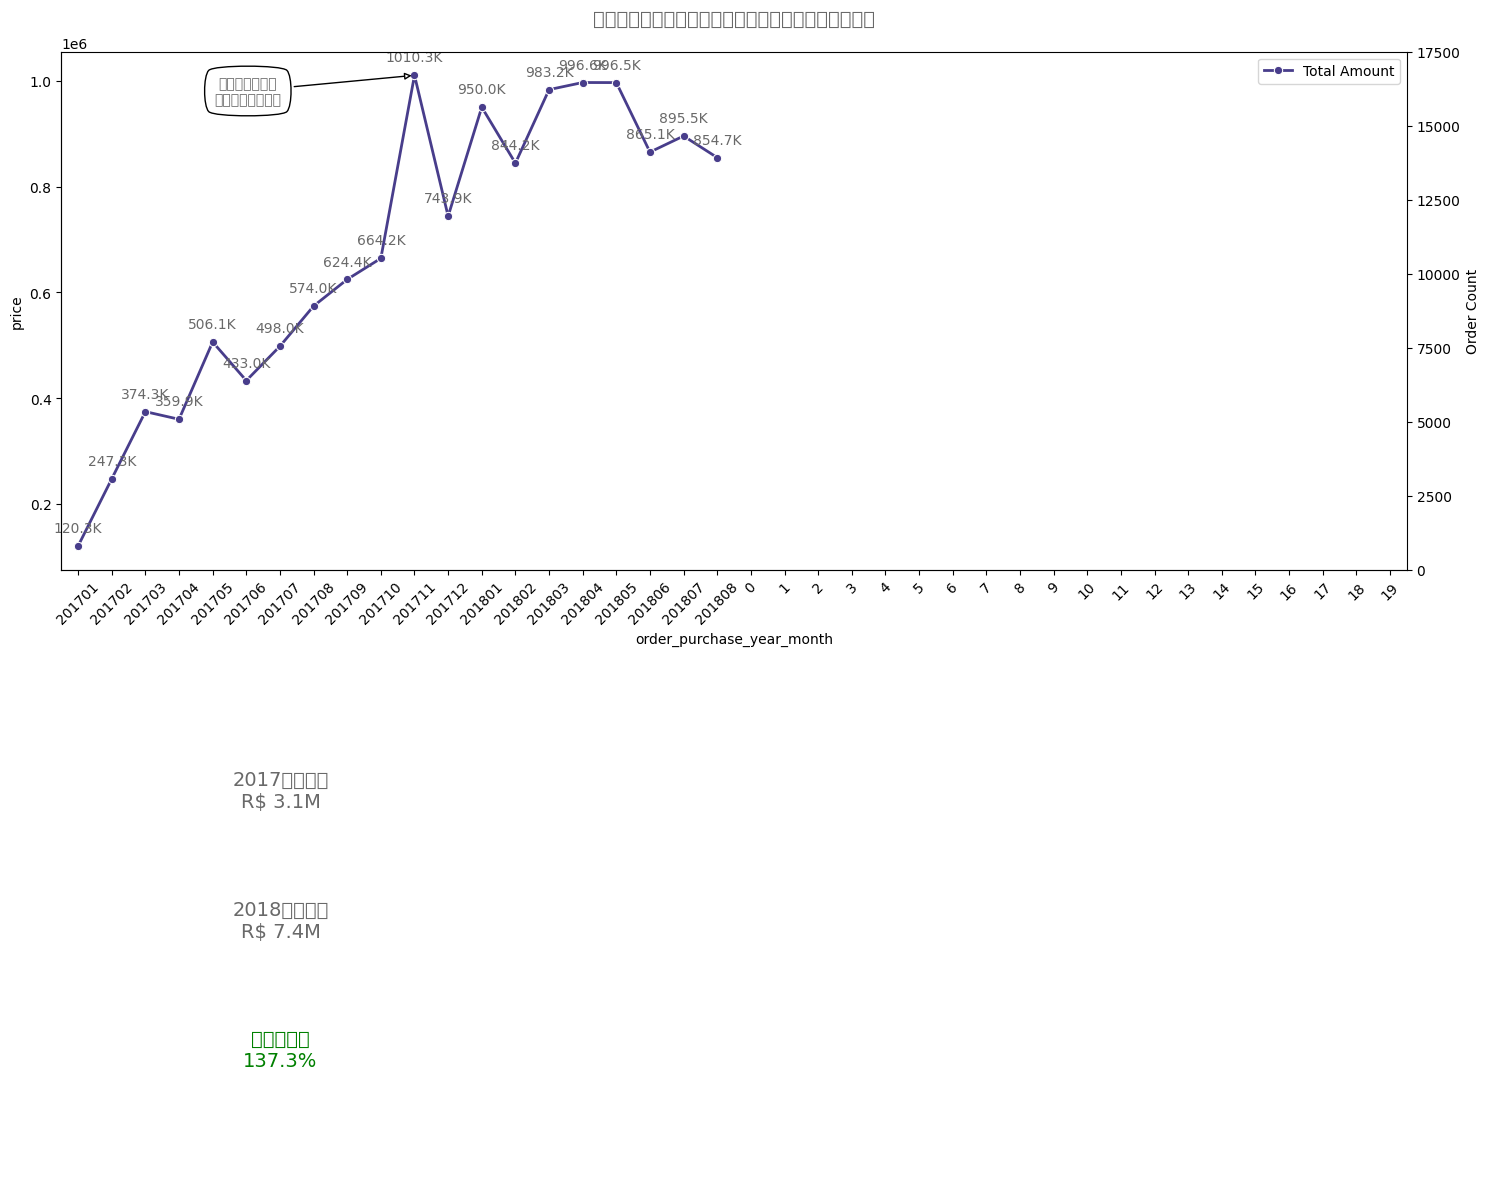

In [17]:
# 导入必要库
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.gridspec import GridSpec

# 自定义边框格式化函数
def format_spines(ax):
    """自定义边框格式"""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('dimgrey')
    ax.spines['bottom'].set_color('dimgrey')

# 创建画布
fig = plt.figure(constrained_layout=True, figsize=(15, 12))

# 定义子图布局
gs = GridSpec(2, 3, figure=fig)
ax1 = fig.add_subplot(gs[0, :])  # 首行全宽
ax2 = fig.add_subplot(gs[1, 0])  # 左下单元格
ax3 = fig.add_subplot(gs[1, 1:])  # 右下合并单元格

# 图表1 - 电商销售趋势（金额+订单数）
# 主坐标轴（左侧）销售额折线图
sns.lineplot(x='order_purchase_year_month', y='price', ax=ax1, 
             data=df_month_aggreg, linewidth=2, color='darkslateblue',
             marker='o', label='Total Amount')

# 副坐标轴（右侧）订单数柱状图（使用标准countplot）
ax1_twx = ax1.twinx()
sns.countplot(x='order_purchase_year_month', data=df_orders_filt, 
              ax=ax1_twx, palette='YlGnBu_r', 
              order=df_month_aggreg.index.tolist())  # 保持与折线图相同顺序
ax1_twx.set_yticks(np.arange(0, 20000, 2500))
ax1_twx.set_ylabel('Order Count')

# 图表美化
format_spines(ax1)
ax1.set_title('电商平台发展趋势：总订单数与销售额（巴西雷亚尔）', 
             size=14, color='dimgrey', pad=20)

# 旋转X轴标签
for tick in ax1.get_xticklabels():
    tick.set_rotation(45)

# 添加数据标签
for x, y in df_month_aggreg.price.items():
    ax1.annotate(f'{y/1000:.1f}K', xy=(x, y), 
                textcoords='offset points', xytext=(0, 10),
                ha='center', color='dimgrey')

# 添加最高点注释
max_point = df_month_aggreg.price.idxmax()
max_x = max_point
max_y = df_month_aggreg.price[max_point]
ax1.annotate('历史最高销售额\n（黑色星期五？）', 
            xy=(max_x, max_y), 
            xytext=(-120, -20),
            textcoords='offset points',
            bbox=dict(boxstyle="round4", fc="w", pad=.8),
            arrowprops=dict(arrowstyle='-|>', fc='w'),
            color='dimgrey', 
            ha='center')

# 图表2 - 销售额增长概况
month_comparison = [
    '201701', '201702', '201703', '201704', '201705', '201706', '201707', '201708',
    '201801', '201802', '201803', '201804', '201805', '201806', '201807', '201808'
]
df_sales_compare = df_month_aggreg.query('order_purchase_year_month in @month_comparison')

# 计算年度销售额
sold_2017 = df_sales_compare.query('order_purchase_year == 2017')['price'].sum()
sold_2018 = df_sales_compare.query('order_purchase_year == 2018')['price'].sum()

# 修正增长率计算
growth_rate = (sold_2018 - sold_2017) / sold_2017 * 100  # 百分比增长率

# 清除坐标轴
ax2.axis('off')

# 添加大号文本
ax2.text(0.5, 0.75, f'2017年销售额\nR$ {sold_2017/1e6:.1f}M', 
        ha='center', va='center', fontsize=14, color='dimgrey')
ax2.text(0.5, 0.5, f'2018年销售额\nR$ {sold_2018/1e6:.1f}M', 
        ha='center', va='center', fontsize=14, color='dimgrey')
ax2.text(0.5, 0.25, f'同比增长率\n{growth_rate:.1f}%', 
        ha='center', va='center', fontsize=14, color='green' if growth_rate > 0 else 'red')

# 图表3留空
ax3.remove()

plt.tight_layout()
plt.show()


In [22]:
# Examples of some portuguese stopwords
pt_stopwords = stopwords.words('portuguese')
print(f'Total portuguese stopwords in the nltk.corpous module: {len(pt_stopwords)}')
pt_stopwords[:10]

Total portuguese stopwords in the nltk.corpous module: 207


['a',
 'à',
 'ao',
 'aos',
 'aquela',
 'aquelas',
 'aquele',
 'aqueles',
 'aquilo',
 'as']

In [23]:
# Defining a function to remove the stopwords and to lower the comments
def stopwords_removal(text, cached_stopwords=stopwords.words('portuguese')):
    """
    Args:
    ----------
    text: list object where the stopwords will be removed [type: list]
    cached_stopwords: stopwords to be applied on the process [type: list, default: stopwords.words('portuguese')]
    """
    
    return [c.lower() for c in text.split() if c.lower() not in cached_stopwords]

In [25]:
# Defining a function to plot the sentiment of a given phrase
def sentiment_analysis(text, pipeline, vectorizer, model):
    """
    Args
    -----------
    text: text string / phrase / review comment to be analysed [type: string]
    pipeline: text prep pipeline built for preparing the corpus [type: sklearn.Pipeline]
    model: classification model trained to recognize positive and negative sentiment [type: model]
    """
    
    # Applying the pipeline
    if type(text) is not list:
        text = [text]
    text_prep = pipeline.fit_transform(text)
    matrix = vectorizer.transform(text_prep)
    
    # Predicting sentiment
    pred = model.predict(matrix)
    proba = model.predict_proba(matrix)
    
    # Plotting the sentiment and its score
    fig, ax = plt.subplots(figsize=(5, 3))
    if pred[0] == 1:
        text = 'Positive'
        class_proba = 100 * round(proba[0][1], 2)
        color = 'seagreen'
    else:
        text = 'Negative'
        class_proba = 100 * round(proba[0][0], 2)
        color = 'crimson'
    ax.text(0.5, 0.5, text, fontsize=50, ha='center', color=color)
    ax.text(0.5, 0.20, str(class_proba) + '%', fontsize=14, ha='center')
    ax.axis('off')
    ax.set_title('Sentiment Analysis', fontsize=14)
    plt.show()

continue